# Using PCA as preprocessing to recognize dog breeds. #

Welcome to this assignment. In this asignment you will see if PCA helps in recognizing dog breeds.<br>
In the end of the Notebook the assignments are given.

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/generated_dogs.csv'
'''
The dataset consists of 10000 dogs who died of old age. It is generated using meta data from dogs.

'''
df = pd.read_csv(url)
df.head()

,Breed,Gender,Age_time_of_death,Height,Weight,Likes,Skills
0,Border Collie,Male,13.3,20.70,40.50,likes_people_better_than_dogs,high_trainability
1,Basset Hound,Male,12.7,13.65,51.02,likes_dogs_better_than_people,no_special_skills
2,Dachshund,Female,14.0,8.59,24.58,likes_dogs_better_than_people,barks_like_hell
3,Boston Terrier,Male,12.3,16.27,20.13,likes_people_better_than_dogs,no_special_skills
4,Chihuahua,Male,15.3,7.14,5.92,likes_dogs_better_than_people,barks_like_hell


# First step #


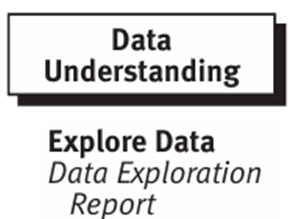


I will help you a little bit. We could try a pairplot.

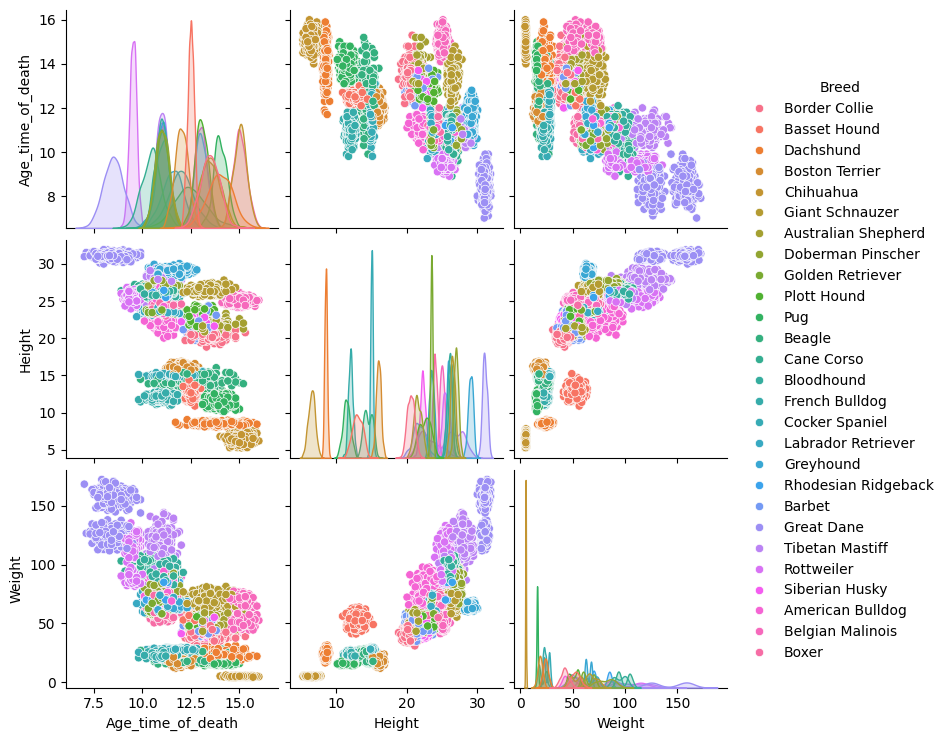

In [2]:
import seaborn as sns

sns.pairplot(df.drop(['Gender','Skills','Likes'],axis=1), hue='Breed')

0) Apply PCA and examine your PC-components. <br>
1) Apply PCA as preprocessing and a classification method of your choice.<br>
2) Compare it with the results you obtained without PCA.



In [3]:
import os
import sys

current_dir = os.getcwd()
path_to_add = os.path.abspath(os.path.join(current_dir, '../../Week_02/Classification'))
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

from ModelEvaluator import ClassificationEvaluator


🔍 STARTING PCA EXPLORATION: MODEL EVALUATOR
   -> Dropped columns: ['Breed']
   -> Data shape for PCA: (10000, 6)
   -> Applying Preprocessing (Scaling/Encoding)...
   -> Fitting PCA (n_components=0.999)...


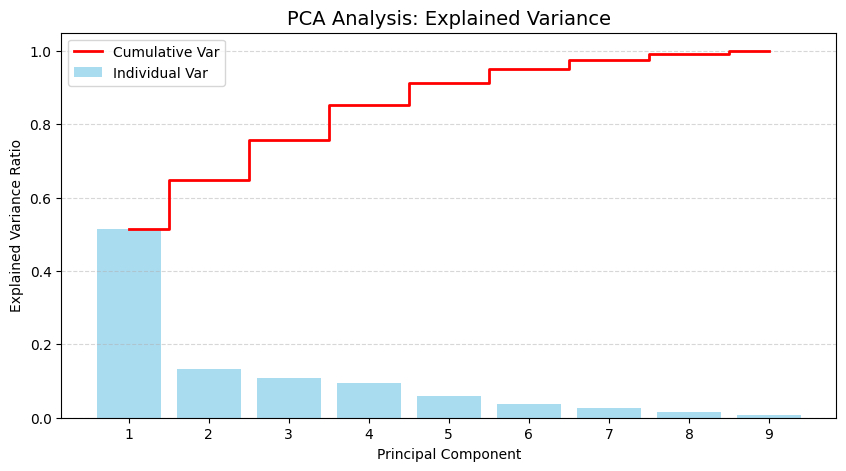

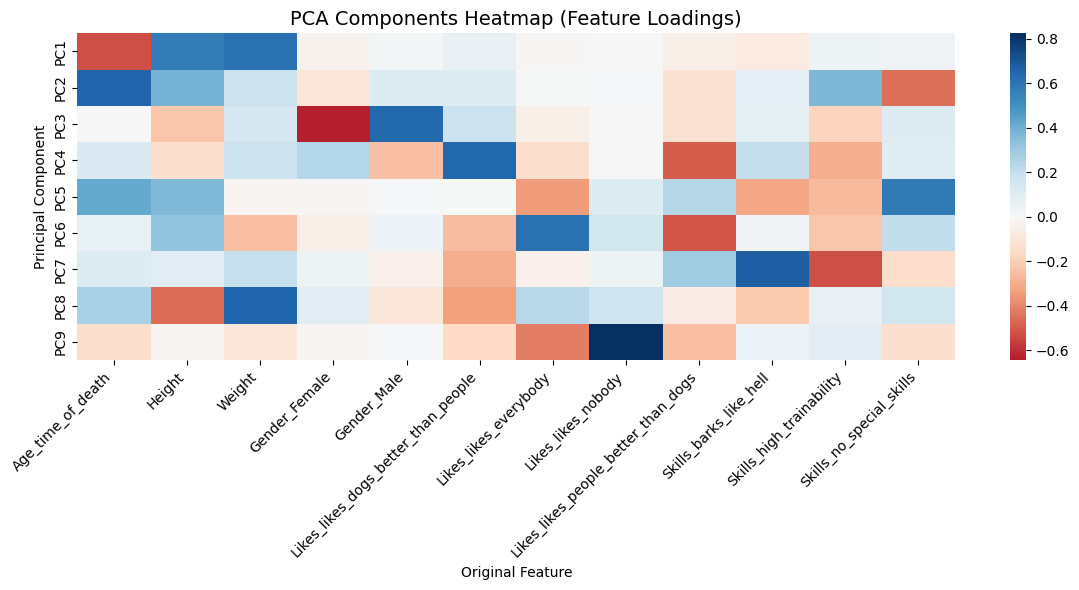

✅ PCA Exploration Completed.


In [4]:
eval = ClassificationEvaluator()
eval.explore_data_with_pca(df,target_col='Breed',n_components=0.999)

In pc3 Male and female are combined in to one



🔍 STARTING PCA EXPLORATION: MODEL EVALUATOR
   -> Dropped columns: ['Breed']
   -> Data shape for PCA: (10000, 6)
   -> Applying Preprocessing (Scaling/Encoding)...
   -> Fitting PCA (n_components=0.999)...


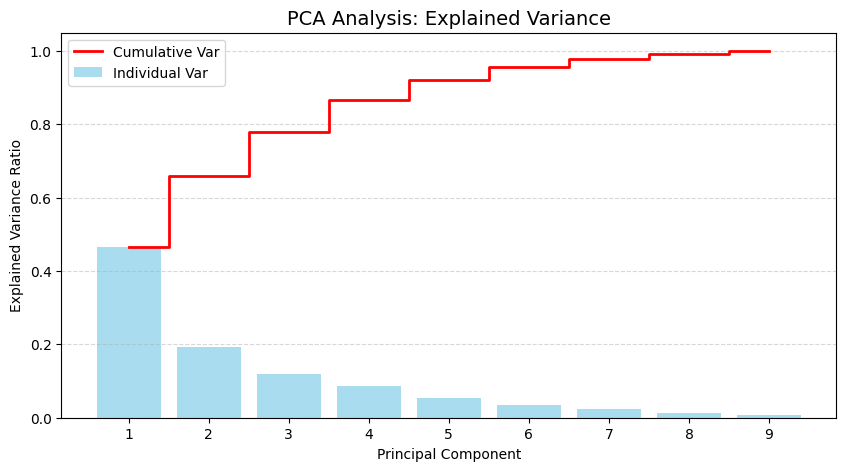

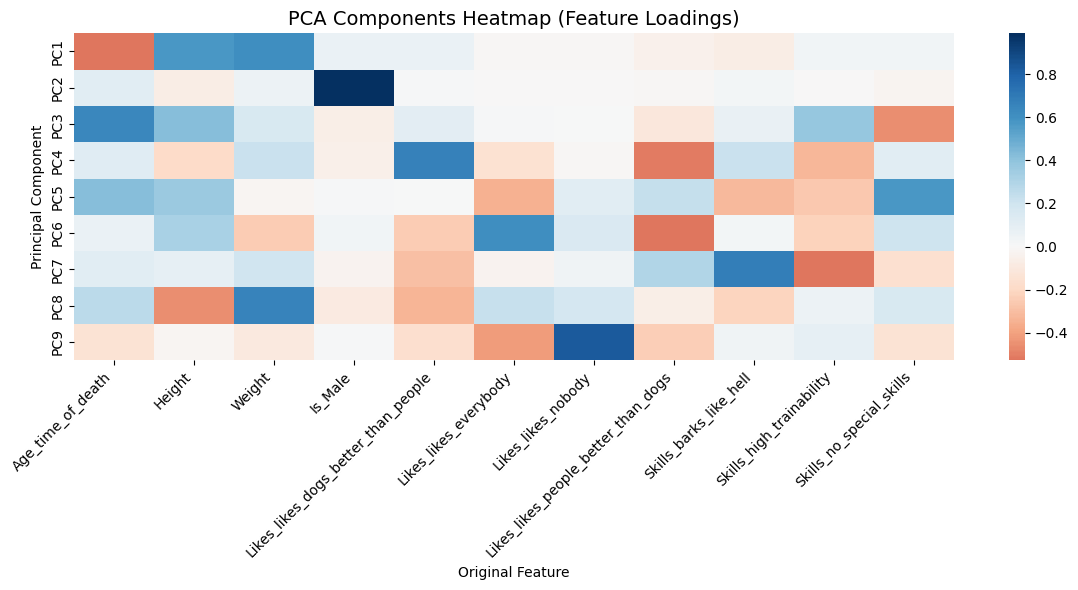

✅ PCA Exploration Completed.


In [5]:
df_eval = df.copy()

mapping = {'Female': 0, 'Male': 1}
    
df_eval['Is_Male'] = df_eval['Gender'].map(mapping)
df_eval.drop(columns=["Gender"],inplace=True)


eval.explore_data_with_pca(df_eval,target_col='Breed',n_components=0.999,)



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

eval.add_model(
    name= 'RandomForestClassifier',
    model= RandomForestClassifier(class_weight='balanced', n_jobs=-1),
    params={
        'n_estimators': [10,25, 50, 100],
        'max_depth': [2, 5, 10, None]
    }
)

eval.add_model(
    name='SVM',
    model=SVC(probability=True, class_weight='balanced', random_state=42),
    params={
        'C': [0.05, 0.1, 1, 10],             
        'kernel': ['linear', 'rbf'],    
        'gamma': ['scale', 'auto']      
    }
)

eval.add_model(
    name='KNN',
    model=KNeighborsClassifier(n_jobs=-1), 
    params={
        'n_neighbors': [3, 5, 7, 9, 15],   
        'weights': ['uniform', 'distance'], 
        'p': [1, 2]                        
    }
)

eval.add_model(
    name='XGBoost',
    model=XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0 
    ),
    params={
        'n_estimators': [100, 200, 400],       
        'learning_rate': [0.01, 0.1, 0.2,0.5,1],
        'max_depth': [3, 6, 10],           
        'scale_pos_weight': [5,10,20]
    }
)

In [7]:
eval.add_option(scaling=True,dummies=True,pca=False)
eval.add_option(scaling=True,dummies=True,pca=True,n_components=1)
eval.add_option(scaling=True,dummies=True,pca=True,n_components=2)
eval.add_option(scaling=True,dummies=True,pca=True,n_components=3)
eval.add_option(scaling=True,dummies=True,pca=True,n_components=4)

eval.add_option(scaling=True,dummies=True,pca=True,n_components=0.95)
eval.add_option(scaling=True,dummies=True,pca=True,n_components=0.99)






In [8]:
eval.run_experiments(df_eval,target_col='Breed')


🚀 START EXPERIMENT: MODEL EVALUATOR
📊 Target Column: 'Breed'
📊 Metrics: ['accuracy', 'f1_macro', 'recall_macro'] (Optimizing for: accuracy)
ℹ️  Target 'Breed' is categorical. Encoding with LabelEncoder.
  27 Classes found

--- ⚙️ Processing Opt0_S1_D1 ---


   ✅ RandomForestClassifier: accuracy=0.9700
   ✅ SVM: accuracy=0.9658
   ✅ KNN: accuracy=0.9671
   ✅ XGBoost: accuracy=0.9680

--- ⚙️ Processing Opt1_S1_D1_PCA ---
   -> PCA enabled (n_components=1)
   ✅ RandomForestClassifier: accuracy=0.3599
   ✅ SVM: accuracy=0.3674
   ✅ KNN: accuracy=0.3458
   ✅ XGBoost: accuracy=0.3640

--- ⚙️ Processing Opt2_S1_D1_PCA ---
   -> PCA enabled (n_components=2)
   ✅ RandomForestClassifier: accuracy=0.7093
   ✅ SVM: accuracy=0.6366
   ✅ KNN: accuracy=0.7076
   ✅ XGBoost: accuracy=0.7180

--- ⚙️ Processing Opt3_S1_D1_PCA ---
   -> PCA enabled (n_components=3)
   ✅ RandomForestClassifier: accuracy=0.8992
   ✅ SVM: accuracy=0.8574
   ✅ KNN: accuracy=0.8784
   ✅ XGBoost: accuracy=0.8967

--- ⚙️ Processing Opt4_S1_D1_PCA ---
   -> PCA enabled (n_components=4)
   ✅ RandomForestClassifier: accuracy=0.9534
   ✅ SVM: accuracy=0.9541
   ✅ KNN: accuracy=0.9525
   ✅ XGBoost: accuracy=0.9495

--- ⚙️ Processing Opt5_S1_D1_PCA ---
   -> PCA enabled (n_components=0.9


=== [Model Evaluator] Top 20 Results (Sorted by accuracy) ===
                 Model                   Config Option_ID   PCA  accuracy  f1_macro  recall_macro  max_depth  n_estimators   C gamma kernel  n_neighbors   p weights  learning_rate  scale_pos_weight
RandomForestClassifier  Opt0 (Scale:Yes PCA:No)      Opt0 False    0.9700    0.9691        0.9691        NaN          50.0 NaN   NaN    NaN          NaN NaN     NaN            NaN               NaN
RandomForestClassifier  Opt0 (Scale:Yes PCA:No)      Opt0 False    0.9694    0.9686        0.9685       10.0         100.0 NaN   NaN    NaN          NaN NaN     NaN            NaN               NaN
RandomForestClassifier  Opt0 (Scale:Yes PCA:No)      Opt0 False    0.9692    0.9683        0.9683        NaN         100.0 NaN   NaN    NaN          NaN NaN     NaN            NaN               NaN
RandomForestClassifier  Opt0 (Scale:Yes PCA:No)      Opt0 False    0.9690    0.9680        0.9680        NaN          25.0 NaN   NaN    NaN      

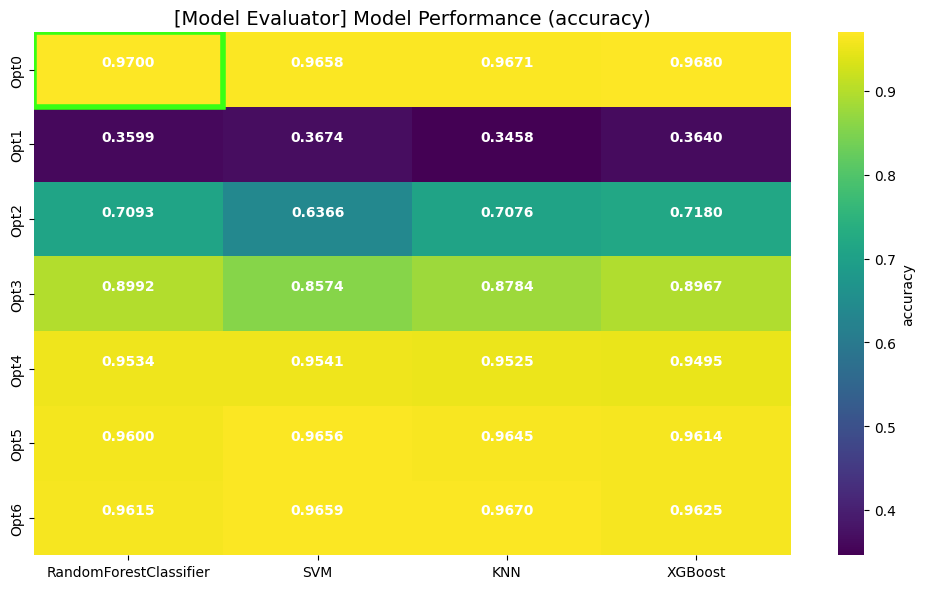

In [9]:
eval.print_results()
eval.plot_heatmap()
eval.plot_confusion_matrix(col_size = 30, row_size =30)


🔍 STARTING PCA EXPLORATION: MODEL EVALUATOR
   -> Dropped columns: ['Breed_Gender']
   -> Data shape for PCA: (10000, 5)
   -> Applying Preprocessing (Scaling/Encoding)...
   -> Fitting PCA (n_components=0.999)...


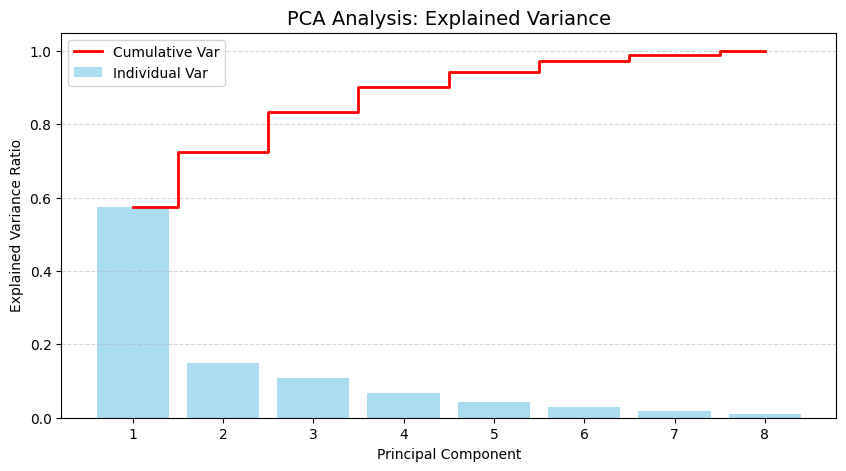

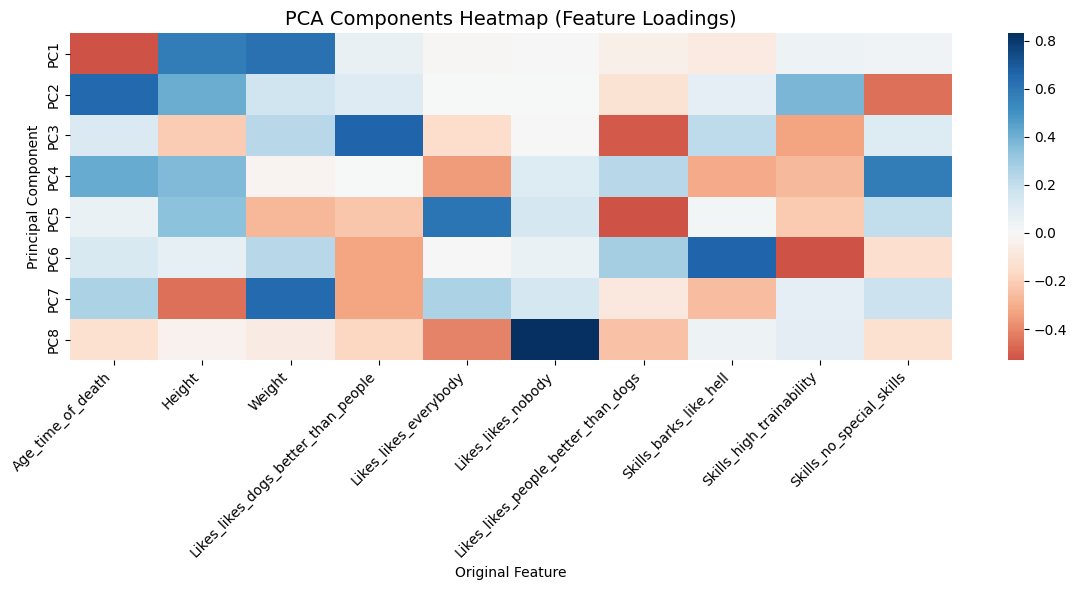

✅ PCA Exploration Completed.

🚀 START EXPERIMENT: MODEL EVALUATOR
📊 Target Column: 'Breed_Gender'
📊 Metrics: ['accuracy', 'f1_macro', 'recall_macro'] (Optimizing for: accuracy)
ℹ️  Target 'Breed_Gender' is categorical. Encoding with LabelEncoder.
  54 Classes found

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ RandomForestClassifier: accuracy=0.8189
   ✅ SVM: accuracy=0.8169
   ✅ KNN: accuracy=0.8117
   ✅ XGBoost: accuracy=0.8164

--- ⚙️ Processing Opt1_S1_D1_PCA ---
   -> PCA enabled (n_components=1)
   ✅ RandomForestClassifier: accuracy=0.2714
   ✅ SVM: accuracy=0.2827
   ✅ KNN: accuracy=0.2582
   ✅ XGBoost: accuracy=0.2831

--- ⚙️ Processing Opt2_S1_D1_PCA ---
   -> PCA enabled (n_components=2)
   ✅ RandomForestClassifier: accuracy=0.6076
   ✅ SVM: accuracy=0.6391
   ✅ KNN: accuracy=0.6327
   ✅ XGBoost: accuracy=0.6121

--- ⚙️ Processing Opt3_S1_D1_PCA ---
   -> PCA enabled (n_components=3)
   ✅ RandomForestClassifier: accuracy=0.7588
   ✅ SVM: accuracy=0.7821
   ✅ KNN: accuracy=0.7655
   

In [10]:
df_eval2 = df.copy()

df_eval2['Breed_Gender'] = df_eval2['Breed'] + '_' + df_eval2['Gender']
df_eval2.drop(columns=["Breed","Gender"],axis=1,inplace=True)

eval.explore_data_with_pca(df_eval2,target_col='Breed_Gender',n_components=0.999)
eval.run_experiments(df_eval2,target_col="Breed_Gender")


=== [Model Evaluator] Top 20 Results (Sorted by accuracy) ===
                 Model                   Config Option_ID   PCA  accuracy  f1_macro  recall_macro  max_depth  n_estimators    C gamma kernel  n_neighbors   p weights  learning_rate  scale_pos_weight
RandomForestClassifier  Opt0 (Scale:Yes PCA:No)      Opt0 False    0.8189    0.8152        0.8175       10.0          50.0  NaN   NaN    NaN          NaN NaN     NaN            NaN               NaN
RandomForestClassifier  Opt0 (Scale:Yes PCA:No)      Opt0 False    0.8180    0.8148        0.8166       10.0         100.0  NaN   NaN    NaN          NaN NaN     NaN            NaN               NaN
                   SVM Opt5 (Scale:Yes PCA:Yes)      Opt5  True    0.8178    0.8085        0.8176        NaN           NaN 10.0 scale    rbf          NaN NaN     NaN            NaN               NaN
                   SVM Opt5 (Scale:Yes PCA:Yes)      Opt5  True    0.8176    0.8091        0.8173        NaN           NaN 10.0  auto    rbf 

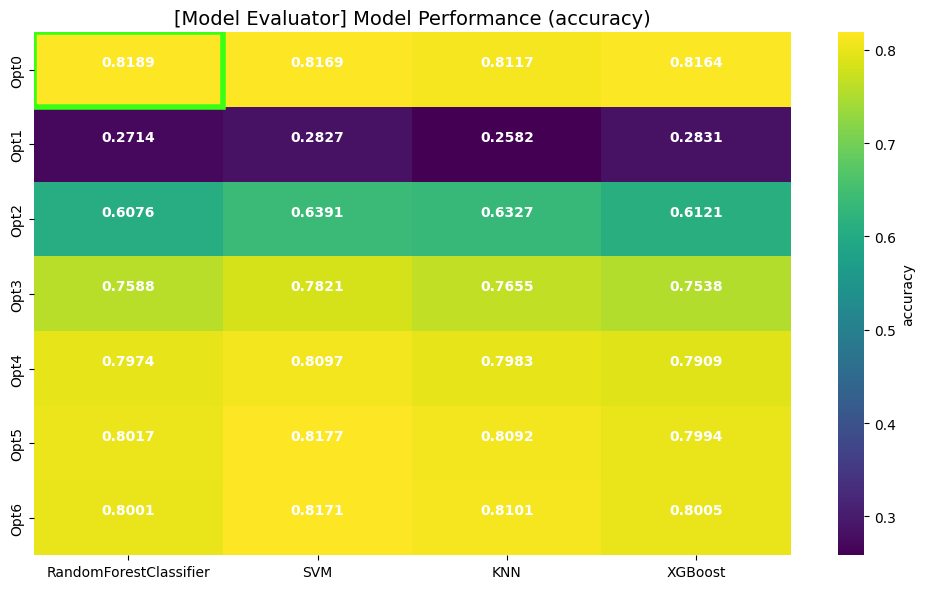

In [11]:
eval.print_results()
eval.plot_heatmap()
eval.plot_confusion_matrix(col_size = 50, row_size =50)